In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score,
                             confusion_matrix, roc_curve, classification_report)

In [4]:
from google.colab import drive
drive.mount("/content/gdrive")
%cd /content/gdrive/MyDrive

Mounted at /content/gdrive
/content/gdrive/MyDrive


In [5]:
df = pd.read_csv('fake_news_dataset.csv')

In [6]:
columns_to_drop = ['title', 'text', 'state', 'char_count', 'has_images', 'has_videos', 'plagerism_score']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # safe drop

In [7]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   id        author date_published          source       category  \
0   1    Jane Smith     30-11-2021       The Onion  Entertainment   
1   2   Emily Davis     02-09-2021    The Guardian     Technology   
2   3      John Doe     13-04-2021  New York Times         Sports   
3   4  Alex Johnson     08-03-2020             CNN         Sports   
4   5   Emily Davis     23-03-2022      Daily Mail     Technology   

   sentiment_score  word_count  readability_score  num_shares  num_comments  \
0            -0.22        1302              66.18       47305           450   
1             0.92         322              41.10       39804           530   
2             0.25         228              30.04       45860           763   
3             0.94         155              75.16       34222           945   
4            -0.01         962              43.90       35934           433   

  political_bias fact_check_rating  is_satirical  trust_score  \
0         Center             FALSE           

In [8]:
# Drop rows with missing labels and clean label column
df = df.dropna(subset=['label'])
df['label'] = df['label'].str.strip().str.lower()
df = df[df['label'].isin(['fake', 'real'])]
df['label'] = df['label'].map({'fake': 1, 'real': 0})

In [9]:
# Print count of fake news
print("Total fake news samples:", df['label'].sum())

Total fake news samples: 2026


In [10]:
df = df.dropna()

In [11]:
feature_cols = ['sentiment_score', 'trust_score']
X = df[feature_cols].values
y = df['label'].values

In [24]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [23]:
# Evaluation Metrics
print("\nEvaluation Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Evaluation Metrics:
Accuracy: 0.49875
Precision: 0.5026881720430108
Recall: 0.9234567901234568
ROC AUC: 0.4715080481325207

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.06      0.11       395
           1       0.50      0.92      0.65       405

    accuracy                           0.50       800
   macro avg       0.47      0.49      0.38       800
weighted avg       0.47      0.50      0.38       800



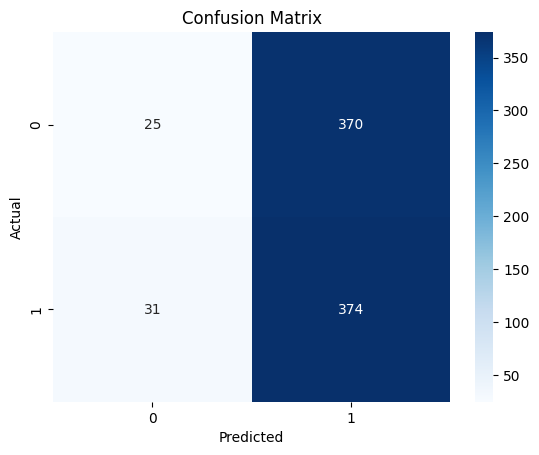

In [22]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

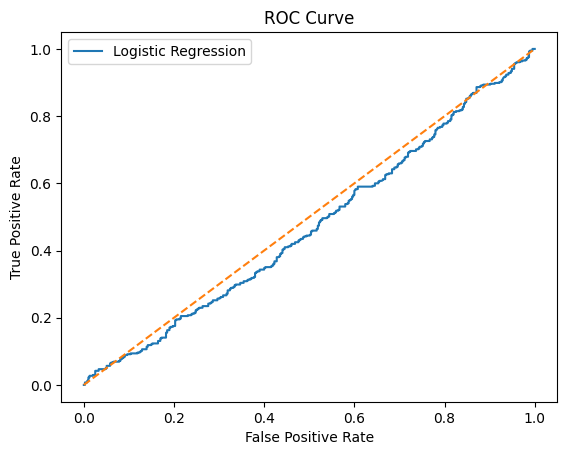

In [21]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

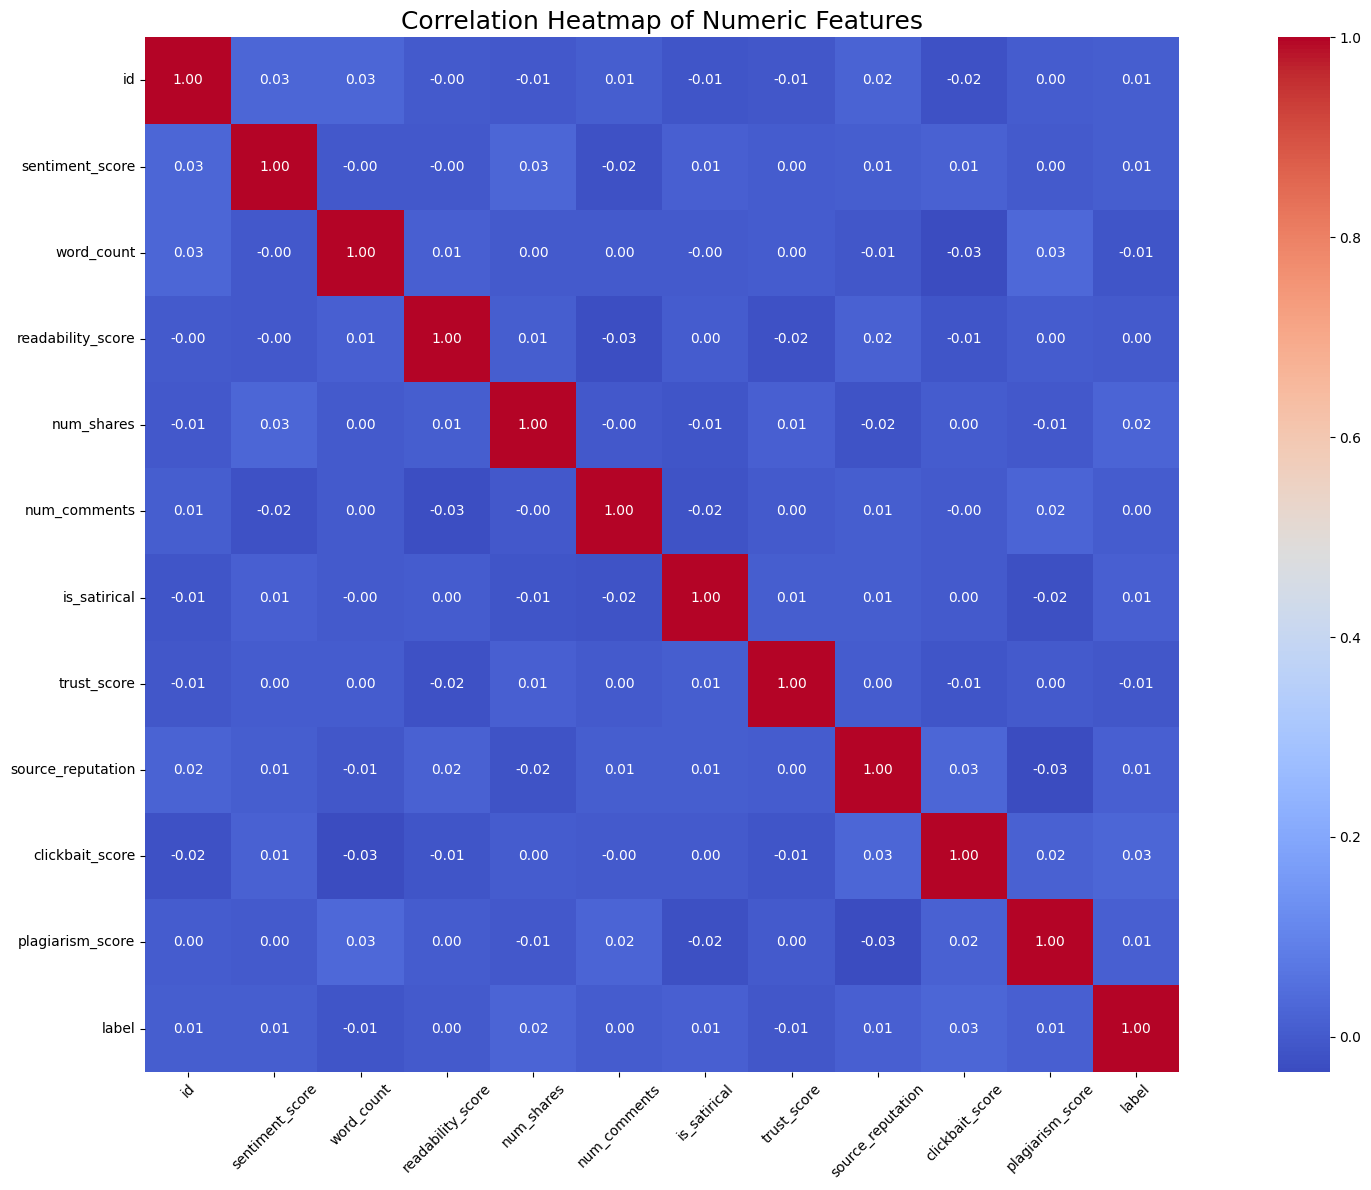

In [18]:
# Correlation Heatmap (full numeric correlation matrix)
corr = df.corr(numeric_only=True)  # in case of any non-numeric columns
plt.figure(figsize=(20, 12))       # larger figure
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numeric Features', fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

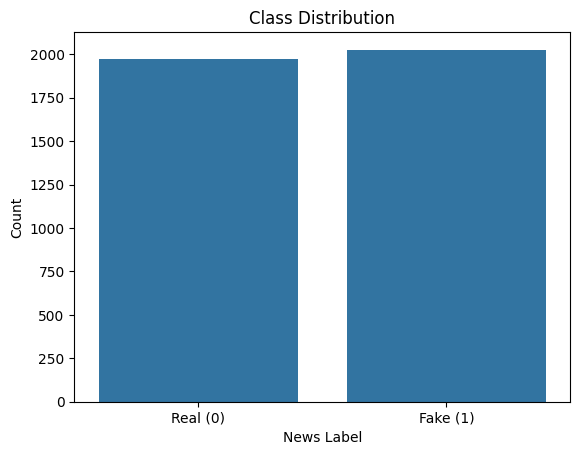

In [20]:
# Class Distribution Plot
sns.countplot(data=df, x='label')
plt.xticks([0, 1], ['Real (0)', 'Fake (1)'])
plt.title('Class Distribution')
plt.xlabel('News Label')
plt.ylabel('Count')
plt.show()